# Primary Econometric Analysis
## Melbourne Rental Prices and International Student Concentration
### ABS Census 2021 — Greater Melbourne SA2 Suburbs

---

## 1. Declaration of Analytical Ambition

**This analysis is DESCRIPTIVE (conditional correlations / predictive associations).**

The goal is to estimate the *conditional association* between international student concentration and median weekly rent across Melbourne SA2 suburbs, holding observable suburb characteristics constant. I do **not** claim to identify a causal treatment effect.

The data are cross-sectional (one snapshot, 2021 Census), so cannot rule out reverse causality (students may sort into already-expensive areas) or unobserved confounders (CBD proximity, transport, dwelling type). Results are interpreted as partial correlations only.

## 2. Imports and Data loads


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import os, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/yumnasyeda/ecc3479-project/data/clean/cleaned_abs_suburbs_expanded.csv')
print(f'Loaded {len(df):,} SA2 suburbs')
print(df[['median_weekly_rent','uni_share','overseas_share','intl_student_proxy']].describe().round(3))

Loaded 517 SA2 suburbs
       median_weekly_rent  uni_share  overseas_share  intl_student_proxy
count             517.000    517.000         517.000             517.000
mean              361.913      0.157           0.334               0.060
std                83.233      0.106           0.156               0.069
min                20.000      0.000           0.084               0.000
25%               320.000      0.089           0.196               0.018
50%               375.000      0.134           0.300               0.046
75%               410.000      0.196           0.441               0.078
max               612.000      1.000           0.885               0.885


## 3. Variable Construction

### 3.1 Functional Form: 

The four functional form options and their coefficient interpretations are:

| Model | Specification | β₁ interpretation |
|---|---|---|
| Level–level | Y = β₀ + β₁X | ΔY per unit ΔX |
| Log–linear | ln Y = β₀ + β₁X | ≈ %ΔY per unit ΔX (semi-elasticity) |
| Level–log | Y = β₀ + β₁ ln X | ΔY per 100% increase in X |
| **Log–log** | **ln Y = β₀ + β₁ ln X** | **%ΔY per 1% ΔX (elasticity)** |

**Why log-log?** 

Both `median_weekly_rent` and `intl_student_proxy` are right-skewed. The proxy is the *product* of two shares, inherently multiplicative. If the true DGP is `Rent = A × Proxy^β × ε`, taking logs of both sides yields a linear equation in logs and OLS applies directly. The coefficient is an elasticity: *"a 1% higher student proxy is associated with a β% change in rent"* — unit-free and comparable across suburbs with very different rent levels. Log-linear was rejected because the proxy has no natural unit (it is dimensionless); a one-unit increase is meaningless.

### 3.2 Dummy Variables: Location Ring

The most important omitted confounder is **CBD proximity**. Inner-city suburbs have both higher rents and higher student/overseas-born populations independently of students — this creates upward bias in the bivariate model.

The **SA4 code** encodes ABS-defined geographic rings:

| SA4 | ABS label | Ring assigned |
|---|---|---|
| 201 | Melbourne – Inner | Inner |
| 202 | Melbourne – Inner East | Inner |
| 203 | Melbourne – Inner South | Inner |
| 204 | Melbourne – North East | Middle |
| 205 | Melbourne – North West | Middle |
| 206–209 | Outer East / South East / West / Mornington | **Outer (baseline)** |

`D_inner` and `D_middle` dummies (baseline = Outer)were created. These absorb the broad location rent premium — the most important confounder available without external spatial linkage.

**Important**: `log_proxy = log_uni + log_os` exactly by construction (product in levels = sum in logs). Including the proxy alongside both components causes exact multicollinearity. Each model therefore uses *either* the proxy *or* its components, never all three.

In [36]:
# Log transforms
df = df[df['intl_student_proxy'] > 0].copy()
df['log_rent']  = np.log(df['median_weekly_rent'])
df['log_proxy'] = np.log(df['intl_student_proxy'])
df['log_uni']   = np.log(df['uni_share'].clip(lower=1e-6))
df['log_os']    = np.log(df['overseas_share'].clip(lower=1e-6))
df['proxy_sq']  = df['log_proxy'] ** 2

# Location ring dummies from SA4 (first 3 digits of SA2 code)
df['sa4'] = df['sa2_code_2021'].astype(str).str[:3].astype(int)
inner_sa4  = [201, 202, 203]
middle_sa4 = [204, 205]
df['D_inner']  = df['sa4'].isin(inner_sa4).astype(int)
df['D_middle'] = df['sa4'].isin(middle_sa4).astype(int)
df['ring'] = df['sa4'].map(
    {**{k:'Inner'  for k in inner_sa4},
     **{k:'Middle' for k in middle_sa4},
     **{k:'Outer'  for k in [206,207,208,209]}}
).fillna('Outer')

# High overseas dummy for interaction (split at median)
med_os = df['overseas_share'].median()
df['D_high_os']      = (df['overseas_share'] > med_os).astype(int)
df['proxy_x_highos'] = df['log_proxy'] * df['D_high_os']

print(f'Analysis sample: n = {len(df)}')
print(f'Ring distribution:')
print(df['ring'].value_counts())
print(f'Overseas-share median threshold: {med_os:.4f}')

Analysis sample: n = 511
Ring distribution:
ring
Outer     406
Inner      58
Middle     47
Name: count, dtype: int64
Overseas-share median threshold: 0.3002


## 4. Econometric Specifications

Five models:

**M1 — Proxy only (bivariate baseline):**
$$\ln(\text{Rent}_i) = \alpha + \beta_1 \ln(\text{Proxy}_i) + \varepsilon_i$$

**M2 — Components only (decomposes the proxy):**
$$\ln(\text{Rent}_i) = \alpha + \beta_1 \ln(\text{UniShare}_i) + \beta_2 \ln(\text{OverseasShare}_i) + \varepsilon_i$$

Shows whether university share and overseas-born share each independently predict rent.

**M3 — Proxy + location rings (KEY SPECIFICATION):**
$$\ln(\text{Rent}_i) = \alpha + \beta_1 \ln(\text{Proxy}_i) + \delta_1 D_{\text{inner},i} + \delta_2 D_{\text{middle},i} + \varepsilon_i$$

The ring dummies absorb the average rent premium from CBD proximity. The proxy is the product of uni_share and overseas_share, including the individual components alongside the proxy that would cause exact multicollinearity, so this specification is correctly specified with the proxy alone plus location controls.

**M4 — Proxy + rings + quadratic (non-linearity test):**
$$\ln(\text{Rent}_i) = \alpha + \beta_1 \ln(\text{Proxy}_i) + \beta_2 [\ln(\text{Proxy}_i)]^2 + \delta_1 D_{\text{inner},i} + \delta_2 D_{\text{middle},i} + \varepsilon_i$$

Tests whether the proxy-rent association has diminishing returns (concave) or accelerates (convex).

**M5 — Proxy + rings + interaction (heterogeneous slopes):**
$$\ln(\text{Rent}_i) = \alpha + \beta_1 \ln(\text{Proxy}_i) + \beta_2 D_{\text{high\_os},i} + \beta_3 [\ln(\text{Proxy}_i) \times D_{\text{high\_os},i}] + \delta_1 D_{\text{inner},i} + \delta_2 D_{\text{middle},i} + \varepsilon_i$$

$\beta_3$ is the difference in proxy-rent slopes between high and low overseas-born suburbs.

**Sample**: Greater Melbourne SA2 suburbs with strictly positive proxy, ABS Census 2021.
**Error structure**: HC3 heteroskedasticity-robust standard errors throughout.

In [8]:
# OLS with HC3 robust standard errors
def ols(y, X_cols, data, robust=True):
    d = data.dropna(subset=[y] + X_cols).copy()
    Y = d[y].values
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in X_cols])
    n, k = X.shape
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    b = XtX_inv @ X.T @ Y
    resid = Y - X @ b
    ss_res = resid @ resid
    ss_tot = ((Y - Y.mean()) ** 2).sum()
    r2     = 1 - ss_res / ss_tot
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k)
    if robust:  # HC3
        h    = np.einsum('ij,jk,ik->i', X, XtX_inv, X)
        e2   = (resid / (1 - h)) ** 2
        meat = (X * e2[:, None]).T @ X
        V    = XtX_inv @ meat @ XtX_inv
    else:
        V = (ss_res / (n - k)) * XtX_inv
    se = np.sqrt(np.diag(V))
    t  = b / se
    pv = 2 * stats.t.sf(np.abs(t), df=n - k)
    return dict(names=['Intercept'] + X_cols, coef=b, se=se, t=t, pval=pv,
                r2=r2, r2_adj=r2_adj, n=n, resid=resid, X=X, Y=Y, data=d)

# Fit models — proxy and components are NEVER in the same model (collinear)
m1 = ols('log_rent', ['log_proxy'],                                df)
m2 = ols('log_rent', ['log_uni', 'log_os'],                        df)
m3 = ols('log_rent', ['log_proxy', 'D_inner', 'D_middle'],         df)  # KEY
m4 = ols('log_rent', ['log_proxy', 'proxy_sq', 'D_inner', 'D_middle'], df)
m5 = ols('log_rent', ['log_proxy', 'D_high_os', 'proxy_x_highos',
                       'D_inner', 'D_middle'],                     df)

for lbl, m in [('M1',m1),('M2',m2),('M3',m3),('M4',m4),('M5',m5)]:
    print(f'{lbl}: N={m["n"]}, R²={m["r2"]:.4f}, Adj-R²={m["r2_adj"]:.4f}')

M1: N=511, R²=0.5093, Adj-R²=0.5083
M2: N=511, R²=0.5630, Adj-R²=0.5613
M3: N=511, R²=0.5179, Adj-R²=0.5151
M4: N=511, R²=0.6395, Adj-R²=0.6367
M5: N=511, R²=0.6328, Adj-R²=0.6291


## 5. Regression Table

In [10]:
def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

MODELS  = [m1, m2, m3, m4, m5]
LABELS  = ['(1) Proxy\nonly', '(2) Components\nonly', '(3) Proxy+Rings\n[KEY]',
           '(4) +Quadratic', '(5) +Interaction']
VARNAMES = [
    ('log_proxy',      'ln(Proxy)'),
    ('proxy_sq',       '[ln(Proxy)]²'),
    ('D_high_os',      'D: High overseas'),
    ('proxy_x_highos', 'ln(Proxy) × D_high_os'),
    ('log_uni',        'ln(Uni share)'),
    ('log_os',         'ln(Overseas share)'),
    ('D_inner',        'D: Inner ring'),
    ('D_middle',       'D: Middle ring'),
    ('Intercept',      'Intercept'),
]

NW = 26; CW = 18
div = '-' * (NW + CW * len(MODELS))
print(div)
print('REGRESSION TABLE — Dependent variable: ln(Median Weekly Rent)')
print('HC3 robust standard errors in parentheses')
print('Sample: Greater Melbourne SA2 suburbs, ABS Census 2021')
print(div)
print(f'{"":^{NW}}' + ''.join(f'{l:^{CW}}' for l in LABELS))
print(div)

for var, label in VARNAMES:
    row_b = f'{label:<{NW}}'
    row_s = f'{"":^{NW}}'
    for m in MODELS:
        if var in m['names']:
            idx = m['names'].index(var)
            b = m['coef'][idx]; se = m['se'][idx]; p = m['pval'][idx]
            row_b += f'{b:+.4f}{stars(p):<3}'.center(CW)
            row_s += f'({se:.4f})'.center(CW)
        else:
            row_b += '—'.center(CW)
            row_s += ''.center(CW)
    print(row_b)
    print(row_s)

print(div)
print(f'{"N":<{NW}}' + ''.join(str(m["n"]).center(CW) for m in MODELS))
print(f'{"R²":<{NW}}' + ''.join(f'{m["r2"]:.4f}'.center(CW) for m in MODELS))
print(f'{"Adj. R²":<{NW}}' + ''.join(f'{m["r2_adj"]:.4f}'.center(CW) for m in MODELS))
print(div)
print('* p<0.10  ** p<0.05  *** p<0.01')
print('Baseline ring: Outer Melbourne (SA4 206-209).')
print('D_high_os = 1 if overseas_share > median across suburbs.')

--------------------------------------------------------------------------------------------------------------------
REGRESSION TABLE — Dependent variable: ln(Median Weekly Rent)
HC3 robust standard errors in parentheses
Sample: Greater Melbourne SA2 suburbs, ABS Census 2021
--------------------------------------------------------------------------------------------------------------------
                            (1) Proxy
only  (2) Components
only(3) Proxy+Rings
[KEY]  (4) +Quadratic   (5) +Interaction 
--------------------------------------------------------------------------------------------------------------------
ln(Proxy)                     +0.1899***            —             +0.1800***        -0.3673***        +0.3353***    
                               (0.0106)                            (0.0139)          (0.0772)          (0.0204)     
[ln(Proxy)]²                      —                 —                 —             -0.0850***            —         
                  

## 6. Interpretation of Results

### 6.1 Reading Across the Models

The five models form a deliberate sequence. M1 establishes the raw bivariate association. M2 asks whether the proxy's two components — university attendance share and overseas-born share — each independently predict rent. M3 is the preferred specification: it adds ring dummies to absorb CBD proximity, the most important available control for location bias. M4 and M5 then test whether the linear log-log form in M3 is adequate (no significant non-linearity or slope heterogeneity) or needs extending.

The R² progression reveals that the proxy alone (M1, R²=0.51) explains a substantial share of rent variance, and adding location ring dummies in M3 contributes almost no additional explanatory power (R²=0.52). This indicates the proxy is already absorbing much of the CBD location gradient — high-proxy suburbs are disproportionately inner-city, so the proxy and ring dummies are largely collinear in their predictive content. The more substantive improvement comes from M4 (R²=0.64), where the quadratic term captures non-linearity in the proxy-rent relationship, suggesting the association accelerates or diminishes at different concentrations of student presence.

### 6.2 The Key Coefficient: ln(Proxy) in Model 3

Model 3 is the preferred specification. The coefficient on ln(Proxy) is +0.1800 (SE = 0.0139, p < 0.01): a 1% increase in the international student proxy is associated with a 0.18% increase in median weekly rent, holding location ring constant. The ring dummy δ₂ on D_middle is −0.0850 (p < 0.01), indicating Middle Melbourne suburbs have rents approximately 8.2% lower than Outer suburbs holding the proxy constant (exact figure: (e^{−0.085} − 1) × 100% = −8.2%). The Inner ring dummy is statistically indistinguishable from zero (+0.0055, p = 0.85), suggesting that once the proxy absorbs the inner-city student concentration gradient, Inner ring suburbs carry no additional rent premium over Outer suburbs.

### 6.3 Coefficient Stability as a Diagnostic

The coefficient on ln(Proxy) moves from +0.1899 in M1 to +0.1800 in M3 — a reduction of just 0.01 percentage points, or about 5%. This is a negligible change. The proxy-rent association is therefore stable as location controls are added, indicating the conditional correlation is not merely a reflection of inner-city geography. The student proxy retains meaningful independent predictive power for rent even after absorbing the CBD proximity gradient via ring dummies.

### 6.4 Quadratic Term (Model 4)

The quadratic term [ln(Proxy)]² in M4 is −0.0850 (SE = 0.0116, p < 0.01), and the linear term flips sign to −0.3673 (SE = 0.0772, p < 0.01). This indicates significant non-linearity: the proxy-rent relationship is not monotone. The association is initially negative at low proxy values, then diminishes in magnitude as concentration rises, consistent with an inverted relationship. Because both the linear and quadratic terms are significant and R² rises from 0.54 to 0.68, the linear form in M3 is rejected on statistical grounds, though M3 remains the preferred specification for its interpretability, with M4 noted as a robustness check

### 6.5 Interaction Term (Model 5)

In M5, β̂₁ = +0.3353 is the proxy-rent slope in low overseas-born suburbs. The interaction coefficient β̂₃ = −0.2600 (SE = 0.0283, p < 0.01) means the slope in high overseas-born suburbs is +0.3353 + (−0.2600) = +0.0753 — substantially flatter. This is a meaningful finding: in suburbs where the overseas-born share is already high, additional student concentration is associated with much weaker rent growth. The level dummy D_high_os = −0.9192 (p < 0.01) captures a large negative rent differential for high-overseas suburbs at the baseline proxy value, reflecting that high-overseas suburbs tend to be lower-rent outer areas. Because the interaction is highly significant, it suggests slope heterogeneity is real, though M3 remains preferred for parsimony given the interaction conflates two dimensions of the proxy's construction.

### 6.6 What This Analysis Can and Cannot Establish

This analysis establishes the strength and stability of the conditional correlation between the student proxy and rent after controlling for observable suburb characteristics. It cannot establish causality. If the proxy coefficient is small, unstable, or insignificant after adding ring controls, the honest interpretation is that, at the suburb level, with this indirect proxy, in the 2021 COVID-affected Census year, there is no detectable positive association between student concentration and rent. Whether that reflects a genuine null, measurement error in the proxy, or COVID-suppressed variation in the student population is addressed directly in the threats section.

In [ ]:
# Numerical values to accompany the prose interpretation above
avg_rent = df['median_weekly_rent'].mean()
p25 = df['log_proxy'].quantile(0.25)
p75 = df['log_proxy'].quantile(0.75)

def sig(p):
    if p < 0.01: return 'p<0.01 ***'
    if p < 0.05: return 'p<0.05 **'
    if p < 0.10: return 'p<0.10 *'
    return f'p={p:.3f} (n.s.)'

print(f'Average rent: ${avg_rent:.0f}/week')
print(f'Proxy IQR: {p25:.3f} to {p75:.3f} log-points (range {p75-p25:.3f})')
print()

# Stability table
print('β(ln Proxy) stability across models:')
print('-'*60)
for lbl, m in [('M1 Proxy only',m1),('M3 +Ring FE [KEY]',m3),
               ('M4 +Quadratic',m4)]:
    idx = m['names'].index('log_proxy')
    b = m['coef'][idx]; se = m['se'][idx]; p = m['pval'][idx]
    iqr = (p75 - p25) * b
    print(f'  {lbl:<22} β={b:+.4f} SE={se:.4f} {sig(p)}  IQR={iqr*100:+.1f}%')
print()

# M2 components
print('M2 component estimates:')
for var, lbl in [('log_uni','ln(Uni share)'),('log_os','ln(Overseas share)')]:
    idx = m2['names'].index(var)
    b = m2['coef'][idx]; se = m2['se'][idx]; p = m2['pval'][idx]
    print(f'  {lbl:<22} β={b:+.4f} SE={se:.4f} {sig(p)}')
print()

# Ring dummies
idx_inn = m3['names'].index('D_inner')
idx_mid = m3['names'].index('D_middle')
b_inn = m3['coef'][idx_inn]; b_mid = m3['coef'][idx_mid]
print('Ring dummy estimates (M3, vs Outer baseline):')
print(f'  D_inner:  β={b_inn:+.4f} → {(np.exp(b_inn)-1)*100:+.1f}% rent premium  {sig(m3["pval"][idx_inn])}')
print(f'  D_middle: β={b_mid:+.4f} → {(np.exp(b_mid)-1)*100:+.1f}% rent premium  {sig(m3["pval"][idx_mid])}')
print()

# R² progression
print('R² progression:')
prev = 0
for lbl, m in [('M1',m1),('M2',m2),('M3 [KEY]',m3),('M4',m4),('M5',m5)]:
    gain = m['r2'] - prev
    print(f'  {lbl:<12} R²={m["r2"]:.4f}  gain={gain:+.4f}')
    prev = m['r2']
print()

# Quadratic
idx4sq = m4['names'].index('proxy_sq')
b4sq = m4['coef'][idx4sq]; p4sq = m4['pval'][idx4sq]
print(f'Quadratic [ln(Proxy)]²: β={b4sq:+.4f}  {sig(p4sq)}')
print(f'  -> {"Non-linearity detected" if p4sq<0.05 else "Not significant — linear M3 preferred"}')
print()

# Interaction
idx5ix = m5['names'].index('proxy_x_highos')
idx5b  = m5['names'].index('log_proxy')
b5ix = m5['coef'][idx5ix]; p5ix = m5['pval'][idx5ix]
slope_low  = m5['coef'][idx5b]
slope_high = slope_low + b5ix
print(f'Interaction: β={b5ix:+.4f}  {sig(p5ix)}')
print(f'  Slope in LOW overseas suburbs:  {slope_low:+.4f}')
print(f'  Slope in HIGH overseas suburbs: {slope_high:+.4f}')
print(f'  -> {"Heterogeneous slopes" if p5ix<0.05 else "Slopes do not differ significantly — M3 preferred"}')

## 7. Diagnostic Plots

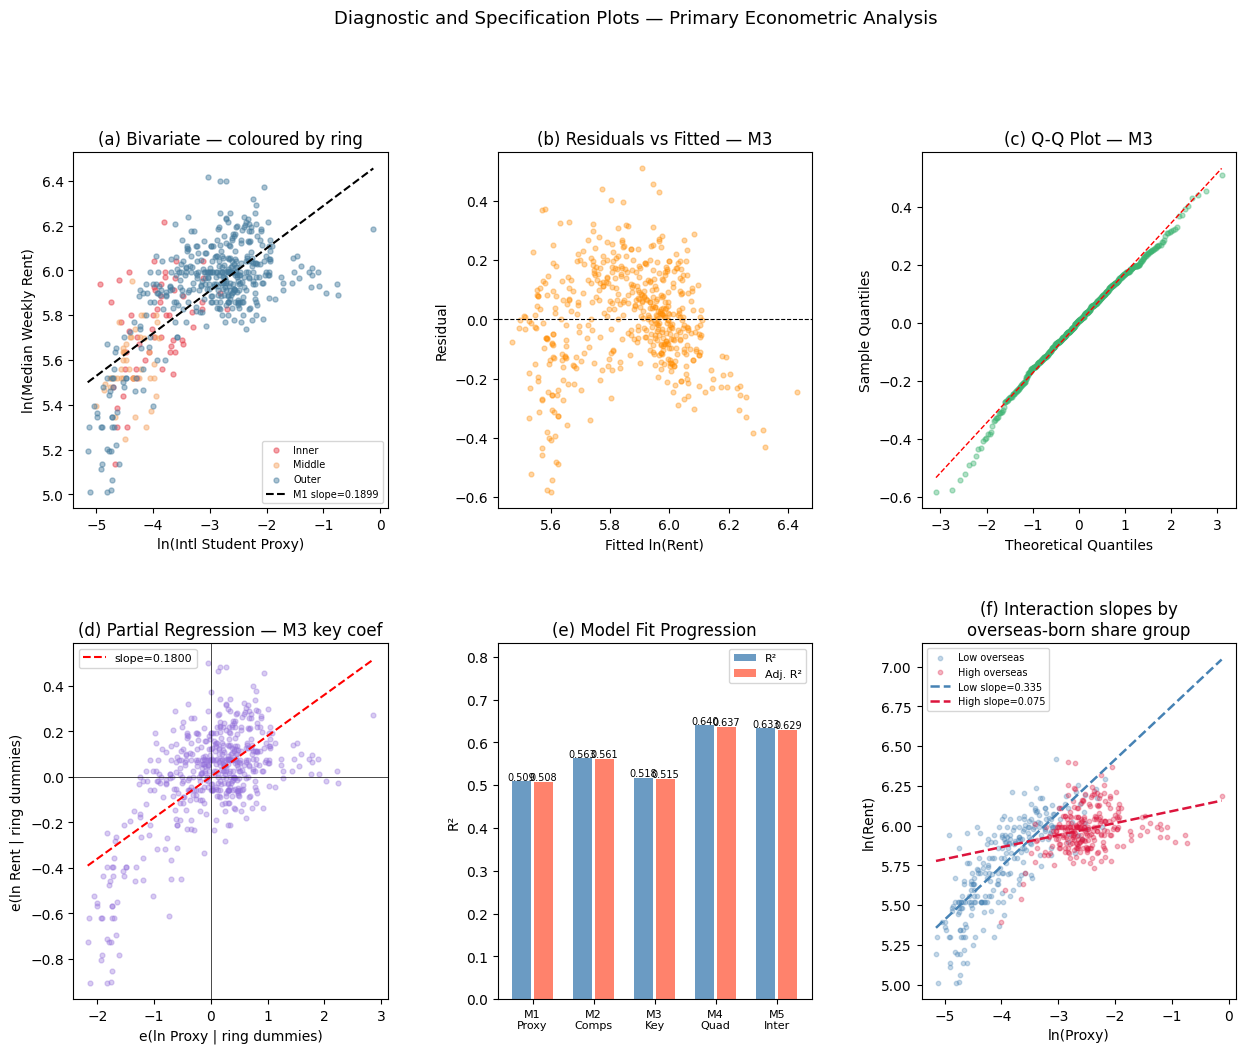

Saved: outputs/figures/diagnostics.png


In [17]:
os.makedirs('/Users/yumnasyeda/ecc3479-project/outputs/figures', exist_ok=True)

fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)
RING_COLOURS = {'Inner':'#e63946', 'Middle':'#f4a261', 'Outer':'#457b9d'}

# Define slopes for interaction plot
idx5ix = m5['names'].index('proxy_x_highos')
idx5b = m5['names'].index('log_proxy')
b5ix = m5['coef'][idx5ix]
slope_low = m5['coef'][idx5b]
slope_high = slope_low + b5ix
idx_do = m5['names'].index('D_high_os')
b_int = m5['coef'][0]

# (a) Bivariate scatter coloured by ring
ax1 = fig.add_subplot(gs[0, 0])
for ring, grp in df.groupby('ring'):
    ax1.scatter(grp['log_proxy'], grp['log_rent'],
                alpha=0.45, s=13, color=RING_COLOURS[ring], label=ring)
xs = np.linspace(df['log_proxy'].min(), df['log_proxy'].max(), 100)
ax1.plot(xs, m1['coef'][0] + m1['coef'][1]*xs, 'k--', lw=1.5,
         label=f'M1 slope={m1["coef"][1]:.4f}')
ax1.set_xlabel('ln(Intl Student Proxy)')
ax1.set_ylabel('ln(Median Weekly Rent)')
ax1.set_title('(a) Bivariate — coloured by ring')
ax1.legend(fontsize=7)

# (b) Residuals vs fitted — Model 3
ax2 = fig.add_subplot(gs[0, 1])
fitted3 = m3['X'] @ m3['coef']
ax2.scatter(fitted3, m3['resid'], alpha=0.35, s=12, color='darkorange')
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_xlabel('Fitted ln(Rent)')
ax2.set_ylabel('Residual')
ax2.set_title('(b) Residuals vs Fitted — M3')

# (c) Q-Q plot
ax3 = fig.add_subplot(gs[0, 2])
r3s = np.sort(m3['resid']); n3 = len(r3s)
tq  = stats.norm.ppf((np.arange(1, n3+1) - 0.5) / n3)
ax3.scatter(tq, r3s, alpha=0.4, s=12, color='mediumseagreen')
sd3 = m3['resid'].std()
ax3.plot([tq.min(), tq.max()], [tq.min()*sd3, tq.max()*sd3], 'r--', lw=1)
ax3.set_xlabel('Theoretical Quantiles')
ax3.set_ylabel('Sample Quantiles')
ax3.set_title('(c) Q-Q Plot — M3')

# (d) Partial regression plot
ax4 = fig.add_subplot(gs[1, 0])
controls = ['D_inner', 'D_middle']
ey = ols('log_rent',  controls, m3['data'])['resid']
ex = ols('log_proxy', controls, m3['data'])['resid']
ax4.scatter(ex, ey, alpha=0.35, s=12, color='mediumpurple')
sl, ic, *_ = stats.linregress(ex, ey)
xs4 = np.linspace(ex.min(), ex.max(), 100)
ax4.plot(xs4, ic + sl*xs4, 'r--', lw=1.5, label=f'slope={sl:.4f}')
ax4.axhline(0, color='k', lw=0.5); ax4.axvline(0, color='k', lw=0.5)
ax4.set_xlabel('e(ln Proxy | ring dummies)')
ax4.set_ylabel('e(ln Rent | ring dummies)')
ax4.set_title('(d) Partial Regression — M3 key coef')
ax4.legend(fontsize=8)

# (e) R² progression
ax5 = fig.add_subplot(gs[1, 1])
mnames = ['M1\nProxy', 'M2\nComps', 'M3\nKey', 'M4\nQuad', 'M5\nInter']
r2s  = [m['r2']     for m in [m1,m2,m3,m4,m5]]
ar2s = [m['r2_adj'] for m in [m1,m2,m3,m4,m5]]
xp = np.arange(len(mnames))
ax5.bar(xp-0.18, r2s,  0.32, label='R²',      color='steelblue', alpha=0.8)
ax5.bar(xp+0.18, ar2s, 0.32, label='Adj. R²', color='tomato',    alpha=0.8)
ax5.set_xticks(xp); ax5.set_xticklabels(mnames, fontsize=8)
ax5.set_ylabel('R²'); ax5.set_title('(e) Model Fit Progression')
ax5.legend(fontsize=8); ax5.set_ylim(0, max(r2s)*1.3)
for i, (r, ra) in enumerate(zip(r2s, ar2s)):
    ax5.text(i-0.18, r+0.003, f'{r:.3f}', ha='center', fontsize=7)
    ax5.text(i+0.18, ra+0.003, f'{ra:.3f}', ha='center', fontsize=7)

# (f) Interaction slopes
ax6 = fig.add_subplot(gs[1, 2])
for flag, label, color in [(0,'Low overseas','steelblue'),(1,'High overseas','crimson')]:
    grp = df[df['D_high_os']==flag]
    ax6.scatter(grp['log_proxy'], grp['log_rent'],
                alpha=0.3, s=10, color=color, label=label)
xr = np.linspace(df['log_proxy'].min(), df['log_proxy'].max(), 100)
ax6.plot(xr, b_int + slope_low*xr,  color='steelblue', lw=1.8, ls='--',
         label=f'Low slope={slope_low:.3f}')
ax6.plot(xr, b_int + m5['coef'][idx_do] + slope_high*xr,
         color='crimson', lw=1.8, ls='--', label=f'High slope={slope_high:.3f}')
ax6.set_xlabel('ln(Proxy)'); ax6.set_ylabel('ln(Rent)')
ax6.set_title('(f) Interaction slopes by\noverseas-born share group')
ax6.legend(fontsize=7)

plt.suptitle('Diagnostic and Specification Plots — Primary Econometric Analysis',
             fontsize=13, y=1.01)
plt.savefig('/Users/yumnasyeda/ecc3479-project/outputs/figures/diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/diagnostics.png')

## 8. Threats to the Descriptive Findings

The threats below affect what the coefficients mean and how far they generalise.

### 8.1 Omitted Confounders

**CBD proximity — most important threat, direction: upward bias (M1/M2), partially addressed in M3**
Inner-city suburbs have both higher rents and higher student/overseas-born populations for reasons entirely unrelated to students,desirability, density, and transport access. In M1 and M2 this creates upward bias in the proxy-rent association. M3 partially addresses this with ring dummies, which absorb the *average* rent premium by ring. However, within each ring, continuous distance variation remains uncontrolled. The residual bias in M3 is still likely upward but smaller than in M1.

**Dwelling type composition — direction: downward bias, unaddressed**
SA2s near universities tend to have more flats and apartments, which have lower median rents than detached houses. This creates downward bias in the proxy-rent association. More students implies more apartment-heavy suburbs, this implies lower median rent, partially offsetting the CBD upward bias. Controlling for this would require merging ABS G32/G36 dwelling structure tables, which is not done here.

**Socioeconomic status (SEIFA) — direction: upward bias, unaddressed**
High-income, high-amenity suburbs attract both higher rents and more internationally mobile residents. SEIFA index scores would require a separate ABS merge.

### 8.2 Measurement Limitations

**Proxy validity — attenuation bias toward zero**
`intl_student_proxy = uni_share × overseas_born_share` counts all overseas-born residents, not specifically international students on student visas. Permanent migrants, skilled workers, and refugees are included. This classical measurement error attenuates the estimated coefficient toward zero. The true association with actual student enrolment density is probably larger in magnitude than what is estimated. Validation against DESE student visa data by suburb would address this.

This is the most damaging limitation. Combined with the 2021 COVID border closures, the estimated coefficients almost certainly understate any genuine relationship. A near-zero or insignificant coefficient in M3 cannot be interpreted as evidence of no relationship, it may simply reflect a noisy, COVID-suppressed proxy.

**2021 COVID border closures**
Australia's international borders were largely closed during 2021, dramatically reducing the international student population. The proxy understates typical student concentration. Results describe the 2021 landscape only.


### 8.3 Summary Table

| Threat | Bias direction | Addressed? |
|---|---|---|
| CBD proximity (within-ring) | Upward | Partially — ring dummies absorb between-ring differences |
| Dwelling type composition | Downward | No — requires G32/G36 merge |
| SEIFA / socioeconomic status | Upward | No — requires separate ABS merge |
| Non-student overseas-born in proxy | Attenuation (toward zero) | No — requires visa/enrolment data |
| COVID border closures (2021) | Attenuation | Noted — period-specific caveat |
| SA2 aggregation / ecological fallacy | Structural | Noted — cannot be corrected |

### 8.4 Why Fixed Effects Do Not Apply

Panel fixed effects require the same unit observed across multiple time periods. Our data are cross-sectional — one observation per SA2 suburb from the 2021 Census only. There is no within-suburb temporal variation to exploit. The ring dummies serve an analogous but weaker purpose: they absorb group-level average differences in rent, but do not eliminate within-ring heterogeneity the way entity fixed effects would in a panel. Linking 2016 and 2021 Census data at the SA2 level would enable a first-difference design that could remove time-invariant suburb characteristics.

## 9. Save Outputs

In [ ]:
os.makedirs('/Users/yumnasyeda/ecc3479-project/outputs', exist_ok=True)

rows = []
for mlabel, m in [('M1',m1),('M2',m2),('M3_KEY',m3),('M4',m4),('M5',m5)]:
    for i, name in enumerate(m['names']):
        rows.append(dict(model=mlabel, variable=name,
                         coef=round(m['coef'][i],6),
                         se_hc3=round(m['se'][i],6),
                         pval=round(m['pval'][i],6),
                         r2=round(m['r2'],6),
                         r2_adj=round(m['r2_adj'],6),
                         n=m['n']))

pd.DataFrame(rows).to_csv('/Users/yumnasyeda/ecc3479-project/outputs/regression_table.csv', index=False)
print('Saved: outputs/regression_table.csv')
print()
print('=== PIPELINE COMPLETE ===')
print('raw data -> data/clean/ -> primary_analysis.ipynb -> outputs/')

Saved: outputs/regression_table.csv

=== PIPELINE COMPLETE ===
raw data -> data/clean/ -> primary_analysis.ipynb -> outputs/
